# Child development and performance (FFCWS subset)

This notebook analyzes a small extract from the **Future of Families and Child Wellbeing Study (FFCWS)** [ICPSR 31622](https://doi.org/10.3886/ICPSR31622.v4): child **reading** and **focused attention** scores, with **mother’s household income** and **education**.

**Outcome (primary):** reading standard score. We also briefly model **focused attention** as a secondary outcome.

**Methods:** descriptive statistics, Pearson correlations (with two-sided p-values), ordinary least squares (OLS) regression, variance inflation factors (VIF), and residual plots. *All results are associational, not causal.*

## Environment and paths

Run from the repository root, or from `notebooks/`; the next cell sets `ROOT` accordingly.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "child_dev_analysis_ready.csv"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT.resolve())
print("Data:", DATA_PATH.exists(), DATA_PATH)


Matplotlib is building the font cache; this may take a moment.


ROOT: /Users/adamzhu/Projects/child-development-analysis
Data: True /Users/adamzhu/Projects/child-development-analysis/data/child_dev_analysis_ready.csv


## 1. Load data and define analysis sample

The CSV was built by `scripts/dataset_prep.py` (missing survey codes recoded to NaN). The analysis file keeps rows with non-missing reading and attention; we drop additional rows with missing income or education for regression.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print("Rows in CSV:", len(df_raw))
print("\nMissing counts (raw file):")
print(df_raw.isna().sum())

df = df_raw.dropna().copy()
df["log_income"] = np.log1p(df["mother_household_income"])

print("\nComplete-case sample (regression):", len(df), "rows")
print("Dropped for missing income/education:", len(df_raw) - len(df))
df.head()


Rows in CSV: 2073

Missing counts (raw file):
id                         0
reading_standard_score     0
focused_attention_score    0
mother_household_income    0
mother_education           1
dtype: int64

Complete-case sample (regression): 2072 rows
Dropped for missing income/education: 1


,id,reading_standard_score,focused_attention_score,mother_household_income,mother_education,log_income
0,2,115.0,10.0,2000.0,1.0,7.601402
1,3,99.0,13.0,36693.0,3.0,10.510369
2,4,103.0,14.0,18000.0,2.0,9.798183
3,8,83.0,6.0,6820.0,3.0,8.827761
4,10,110.0,9.0,36998.0,3.0,10.518646


## 2. Summary statistics

Income is right-skewed; models use `log(1 + income)` to dampen leverage from high values.

In [3]:
df.describe().round(2)


,id,reading_standard_score,focused_attention_score,mother_household_income,mother_education,log_income
count,2072.00,2072.00,2072.00,2072.00,2072.00,2072.00
mean,2426.44,100.30,12.74,35310.36,2.36,9.87
std,1398.03,14.76,3.30,40007.08,0.98,1.50
min,2.00,54.00,1.00,0.00,1.00,0.00
25%,1193.25,90.00,11.00,10862.25,1.00,9.29
50%,2463.50,102.00,13.00,24000.00,2.00,10.09
75%,3591.25,109.00,15.00,48003.00,3.00,10.78
max,4897.00,186.00,19.00,688444.00,4.00,13.44


## 3. Distributions

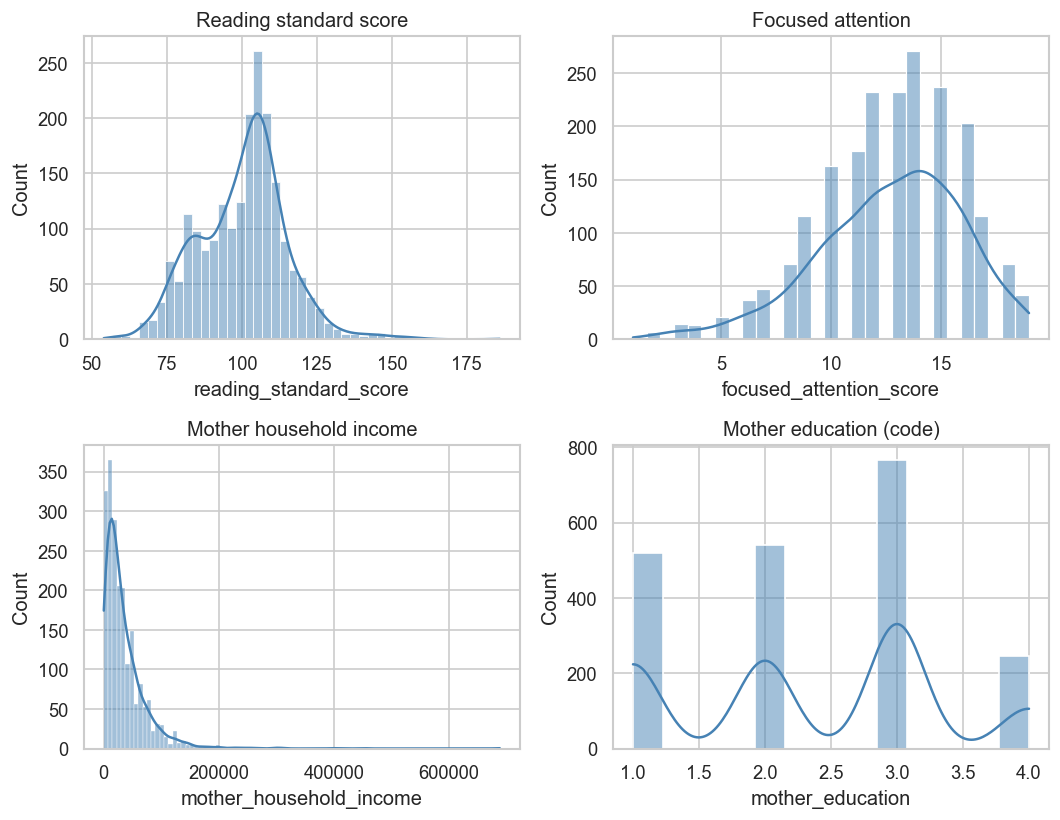

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.ravel()
for ax, col, title in zip(
    axes,
    ["reading_standard_score", "focused_attention_score", "mother_household_income", "mother_education"],
    ["Reading standard score", "Focused attention", "Mother household income", "Mother education (code)"],
):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(title)
plt.tight_layout()
fig.savefig(FIG_DIR / "distributions.png", dpi=150)
plt.show()


In [5]:
edu_counts = df["mother_education"].value_counts().sort_index()
print("Mother education (code) counts:\n", edu_counts)


Mother education (code) counts:
 mother_education
1.0    519
2.0    541
3.0    767
4.0    245
Name: count, dtype: int64


## 4. Reading score by mother’s education

Education is an ordinal category in the survey (numeric codes 1–4 in this extract). The boxplot treats codes as discrete groups.

/var/folders/jz/k6xl9ft537l7rtp7srgq3_880000gn/T/ipykernel_76491/3909049063.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mother_education", y="reading_standard_score", ax=ax, palette="Blues")


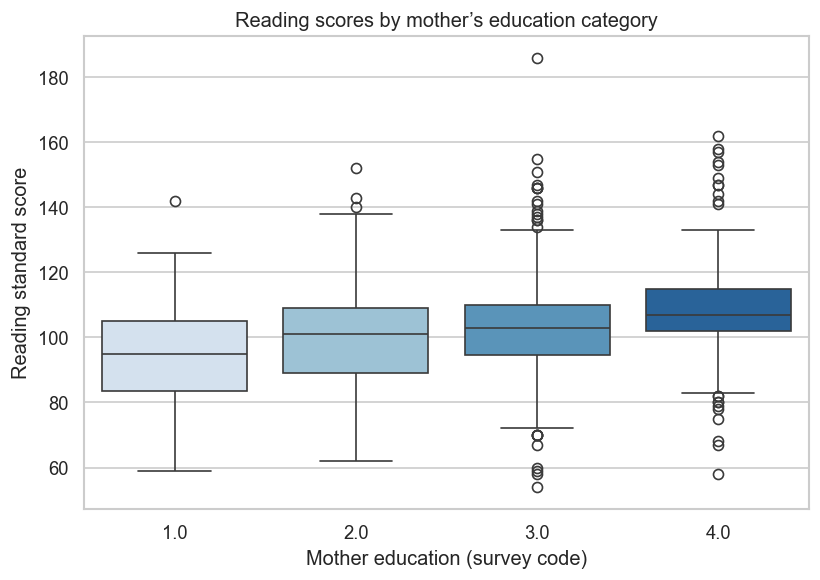

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="mother_education", y="reading_standard_score", ax=ax, palette="Blues")
ax.set_xlabel("Mother education (survey code)")
ax.set_ylabel("Reading standard score")
ax.set_title("Reading scores by mother’s education category")
plt.tight_layout()
fig.savefig(FIG_DIR / "reading_by_education.png", dpi=150)
plt.show()


## 5. Pearson correlations

Pairwise linear associations among analysis variables (complete cases).

In [7]:
cols = [
    "reading_standard_score",
    "focused_attention_score",
    "mother_household_income",
    "mother_education",
]
labels = ["Reading", "Attention", "Income", "Mother edu."]

corr = df[cols].corr()
r_display = corr.copy()
r_display.index = labels
r_display.columns = labels

rows = []
for i, a in enumerate(cols):
    for j, b in enumerate(cols):
        if j <= i:
            continue
        r, p = stats.pearsonr(df[a], df[b])
        rows.append({"var_a": labels[i], "var_b": labels[j], "r": r, "p_value": p})
pearson_tbl = pd.DataFrame(rows)
print("Correlation matrix:")
display(r_display.round(3))
print("\nPairwise Pearson r and two-sided p-values:")
display(pearson_tbl.assign(r=lambda t: t["r"].round(3), p_value=lambda t: t["p_value"].apply(lambda x: f"{x:.2e}" if x < 1e-4 else round(x, 4))))


Correlation matrix:


,Reading,Attention,Income,Mother edu.
Reading,1.000,0.279,0.203,0.280
Attention,0.279,1.000,0.106,0.115
Income,0.203,0.106,1.000,0.416
Mother edu.,0.280,0.115,0.416,1.000



Pairwise Pearson r and two-sided p-values:


,var_a,var_b,r,p_value
0,Reading,Attention,0.279,2.11e-38
1,Reading,Income,0.203,1.24e-20
2,Reading,Mother edu.,0.280,1.45e-38
3,Attention,Income,0.106,1.44e-06
4,Attention,Mother edu.,0.115,1.56e-07
5,Income,Mother edu.,0.416,2.65e-87


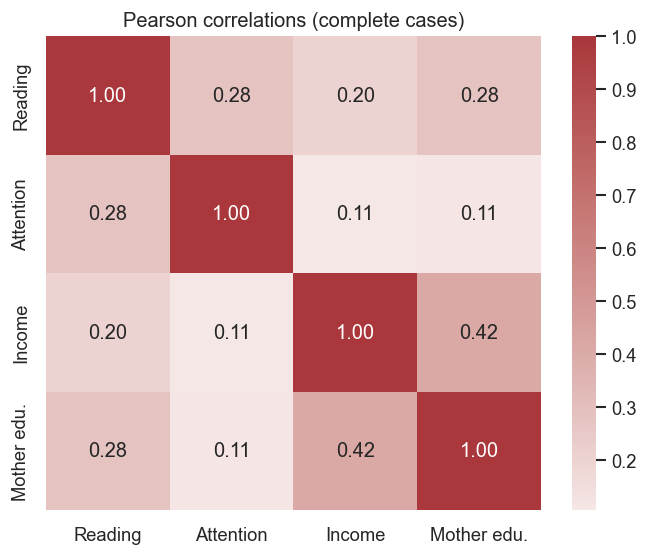

In [8]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax,
            xticklabels=labels, yticklabels=labels)
ax.set_title("Pearson correlations (complete cases)")
plt.tight_layout()
fig.savefig(FIG_DIR / "corr_heatmap.png", dpi=150)
plt.show()


## 6. Scatter plots with OLS fit line

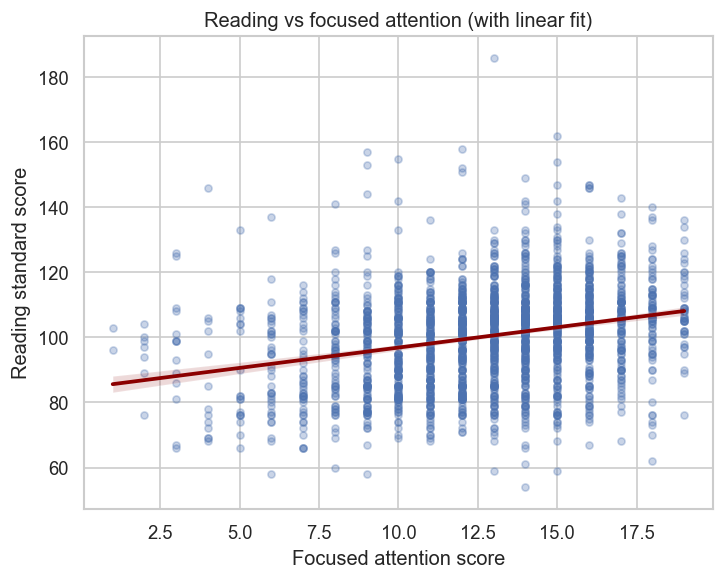

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.regplot(
    data=df,
    x="focused_attention_score",
    y="reading_standard_score",
    scatter_kws={"alpha": 0.3, "s": 18},
    line_kws={"color": "darkred"},
    ax=ax,
)
ax.set_title("Reading vs focused attention (with linear fit)")
ax.set_xlabel("Focused attention score")
ax.set_ylabel("Reading standard score")
plt.tight_layout()
fig.savefig(FIG_DIR / "reading_vs_attention.png", dpi=150)
plt.show()


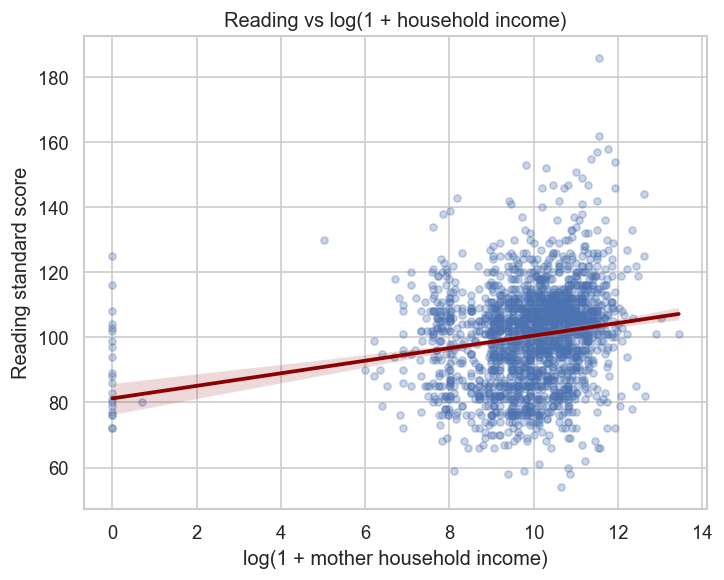

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.regplot(
    data=df,
    x="log_income",
    y="reading_standard_score",
    scatter_kws={"alpha": 0.3, "s": 18},
    line_kws={"color": "darkred"},
    ax=ax,
)
ax.set_title("Reading vs log(1 + household income)")
ax.set_xlabel("log(1 + mother household income)")
ax.set_ylabel("Reading standard score")
plt.tight_layout()
fig.savefig(FIG_DIR / "reading_vs_log_income.png", dpi=150)
plt.show()


## 7. OLS regression — reading as outcome

We compare nested specifications:

1. **M1:** attention only  
2. **M2:** attention + socioeconomic measures (log income, education)  
3. **M3:** same as M2 (full model); report VIF and residuals below

Coefficients are interpretable holding other linear terms fixed (still not causal).

In [11]:
y = df["reading_standard_score"]
X1 = sm.add_constant(df[["focused_attention_score"]])
X2 = sm.add_constant(df[["focused_attention_score", "log_income", "mother_education"]])

m1 = sm.OLS(y, X1).fit()
m2 = sm.OLS(y, X2).fit()

def grab(m, name):
    return pd.Series({
        "model": name,
        "n": int(m.nobs),
        "R2": m.rsquared,
        "adj_R2": m.rsquared_adj,
        "AIC": m.aic,
    })

comp = pd.DataFrame([grab(m1, "M1 attention"), grab(m2, "M2 + SES")])
display(comp.round(4))

print("Nested F-test: does adding log income + education improve fit? (M2 vs M1)")
print(m2.compare_f_test(m1))


,model,n,R2,adj_R2,AIC
0,M1 attention,2072,0.0779,0.0775,16871.1597
1,M2 + SES,2072,0.1466,0.1453,16714.8859


Nested F-test: does adding log income + education improve fit? (M2 vs M1)
(np.float64(83.15694308167717), np.float64(1.837239038318268e-35), np.float64(2.0))


In [12]:
X = sm.add_constant(df[["focused_attention_score", "log_income", "mother_education"]])
reading_model = sm.OLS(y, X).fit()
reading_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     reading_standard_score   R-squared:                       0.147
Model:                                OLS   Adj. R-squared:                  0.145
Method:                     Least Squares   F-statistic:                     118.4
Date:                    Thu, 19 Mar 2026   Prob (F-statistic):           9.38e-71
Time:                            22:33:25   Log-Likelihood:                -8353.4
No. Observations:                    2072   AIC:                         1.671e+04
Df Residuals:                        2068   BIC:                         1.674e+04
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      70.2001      2.204     31.857      0.000      65.879      74.522
focused_attention_score     1.0923      0.092     11.896      0.000       0.912       1.272
log_income                  0.8539      0.216      3.959      0.000       0.431       1.277
mother_education            3.2925      0.330      9.989      0.000       2.646       3.939
==============================================================================
Omnibus:                       89.139   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              189.532
Skew:                           0.276   Prob(JB):                     6.98e-42
Kurtosis:                       4.375   Cond. No.                         122.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 8. Variance inflation factors (VIF)

VIF quantifies how much predictor variance is inflated by linear overlap with other predictors. Values above ~5–10 sometimes draw scrutiny.

In [13]:
X_no_const = df[["focused_attention_score", "log_income", "mother_education"]]
vif_df = pd.DataFrame({
    "predictor": X_no_const.columns,
    "VIF": [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])],
})
vif_df


,predictor,VIF
0,focused_attention_score,13.265684
1,log_income,18.882836
2,mother_education,7.863983


## 9. Residual diagnostics (reading model)

Check mean of residuals ~0 and scan for strong nonlinear patterns or heteroskedasticity (informal).

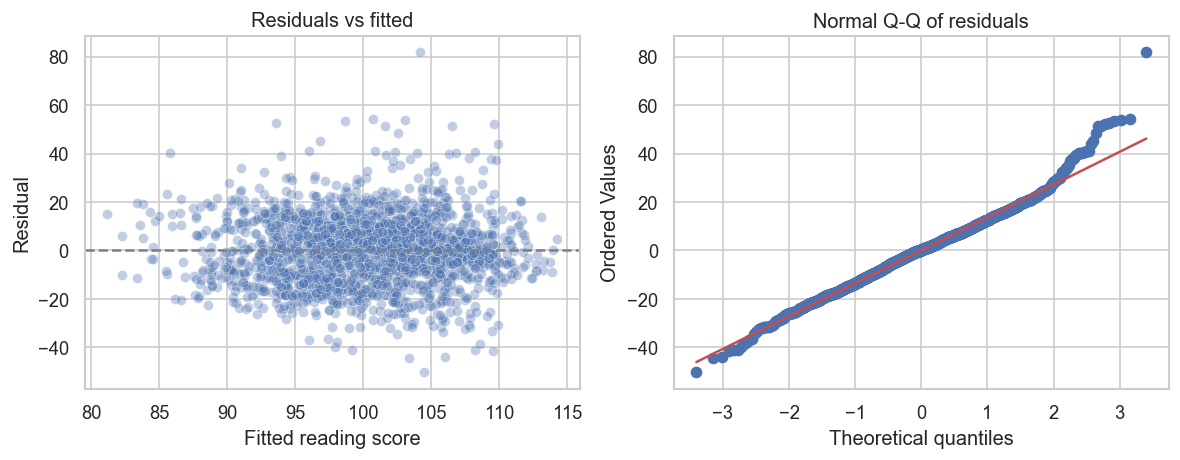

In [14]:
fitted = reading_model.fittedvalues
resid = reading_model.resid

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=fitted, y=resid, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color="gray", ls="--")
axes[0].set_xlabel("Fitted reading score")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs fitted")

stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q of residuals")
plt.tight_layout()
fig.savefig(FIG_DIR / "residual_diagnostics.png", dpi=150)
plt.show()


## 10. Secondary outcome: focused attention

Mirror specification with **focused attention** as the dependent variable to see whether SES and reading line up in a symmetric way. (Causality is still not implied.)

In [15]:
y2 = df["focused_attention_score"]
X_attn = sm.add_constant(df[["reading_standard_score", "log_income", "mother_education"]])
attention_model = sm.OLS(y2, X_attn).fit()
attention_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     focused_attention_score   R-squared:                       0.082
Model:                                 OLS   Adj. R-squared:                  0.081
Method:                      Least Squares   F-statistic:                     61.57
Date:                     Thu, 19 Mar 2026   Prob (F-statistic):           4.01e-38
Time:                             22:33:26   Log-Likelihood:                -5323.4
No. Observations:                     2072   AIC:                         1.065e+04
Df Residuals:                         2068   BIC:                         1.068e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      5.5023      0.612      8.998      0.000       4.303       6.701
reading_standard_score     0.0586      0.005     11.896      0.000       0.049       0.068
log_income                 0.1209      0.050      2.413      0.016       0.023       0.219
mother_education           0.0703      0.078      0.899      0.369      -0.083       0.224
==============================================================================
Omnibus:                      110.346   Durbin-Watson:                   2.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              129.562
Skew:                          -0.563   Prob(JB):                     7.35e-29
Kurtosis:                       3.481   Cond. No.                         898.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 11. Brief interpretation

- **Descriptives:** See tables and plots above for scale and spread; income is skewed, motivating the log transform.  
- **Correlations:** Reading and attention are positively correlated; income and education correlate with reading in this sample.  
- **Regression:** Adding SES to attention improves fit (compare M1 vs M2). Coefficients and significance tests are in the `reading_model` and `attention_model` tables.  
- **Diagnostics:** VIFs here are high (~8–19), so SES and attention overlap a lot linearly—interpret individual coefficients cautiously. Residual plots still help spot gross assumption violations. This does not replace survey weights or a full design-based analysis.  
- **Limitations:** No sampling weights; single wave / variable selection; omitted confounders; education coded ordinally as numeric; cross-sectional data cannot support causal claims. For publication-quality work, follow [FFCWS documentation](https://ffcws.princeton.edu/documentation) and citation requirements.

In [16]:
summary_lines = [
    f"N (complete cases) = {len(df)}",
    f"Reading ~ attention + log_income + education: R-squared = {reading_model.rsquared:.3f}, Adj. R-squared = {reading_model.rsquared_adj:.3f}",
    "",
    "Coefficients (reading model):",
    reading_model.params.round(4).to_string(),
    "",
    f"Attention ~ reading + log_income + education: R-squared = {attention_model.rsquared:.3f}",
    attention_model.params.round(4).to_string(),
]
print("\n".join(summary_lines))


N (complete cases) = 2072
Reading ~ attention + log_income + education: R-squared = 0.147, Adj. R-squared = 0.145

Coefficients (reading model):
const                      70.2001
focused_attention_score     1.0923
log_income                  0.8539
mother_education            3.2925

Attention ~ reading + log_income + education: R-squared = 0.082
const                     5.5023
reading_standard_score    0.0586
log_income                0.1209
mother_education          0.0703
